In [1]:
from SDP_interaction_inference.constraints import Constraint
from SDP_interaction_inference import optimization
from SDP_interaction_inference.dataset import Dataset
from SDP_interaction_inference.correlation import Correlation
from SDP_interaction_inference import utils
from SDP_interaction_inference import optimization_MOSEK
from SDP_interaction_inference import optimization_utils
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import json
import scipy
import tqdm
from copy import deepcopy
import matplotlib.patches
import corner
import plotly
import plotly.graph_objects as go

## Data Loading

In [2]:
# load counts
data_FIB = pd.read_csv("../../Moment-equations/Real-Data-2/Data/GSE151334_FIB_counts_thresh.csv", index_col=0)

# load capture
beta_FIB = np.loadtxt("../../Moment-equations/Real-Data-2/Capture/beta_FIB.txt")

# load cell cycle phases
phases = pd.read_csv("../R-Notebooks/Cell-Cycle/phase.csv", index_col=0)

# select FIB cells
phases_FIB = phases.loc[data_FIB.columns]

# select cells by phase: use per cell type phases
FIB_G1_mask = (phases_FIB['Phase_per_type'] == "G1")
FIB_S_mask = (phases_FIB['Phase_per_type'] == "S")
FIB_G2M_mask = (phases_FIB['Phase_per_type'] == "G2M")

# separate data by phase
data_FIB_G1 = data_FIB.loc[:, FIB_G1_mask]
data_FIB_S = data_FIB.loc[:, FIB_S_mask]
data_FIB_G2M = data_FIB.loc[:, FIB_G2M_mask]

# separate capture by phase
beta_FIB_G1 = beta_FIB[FIB_G1_mask]
beta_FIB_S = beta_FIB[FIB_S_mask]
beta_FIB_G2M = beta_FIB[FIB_G2M_mask]

# amounts
print(f"Total cells = {beta_FIB.size}")
print(f"Cell in phase \nG1 = {beta_FIB_G1.size} \nS = {beta_FIB_S.size} \nG2M = {beta_FIB_G2M.size}")

Total cells = 277
Cell in phase 
G1 = 39 
S = 108 
G2M = 130


In [3]:
# load RNA types
biotypes_dict = json.load(open("../../Moment-equations/Real-Data-2/Biotypes/biotypes_FIB.json"))

# select indices of protein coding mRNA and non-coding miRNA
pcRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "protein_coding"]
miRNA_indices = [idx for idx, btype in enumerate(biotypes_dict.values()) if btype == "miRNA"]

# select protein coding genes
data_FIB_pcRNA = data_FIB.iloc[pcRNA_indices]
data_FIB_G1_pcRNA = data_FIB_G1.iloc[pcRNA_indices]
data_FIB_S_pcRNA = data_FIB_S.iloc[pcRNA_indices]
data_FIB_G2M_pcRNA = data_FIB_G2M.iloc[pcRNA_indices]

# select protein coding genes
data_FIB_miRNA = data_FIB.iloc[miRNA_indices]
data_FIB_G1_miRNA = data_FIB_G1.iloc[miRNA_indices]
data_FIB_S_miRNA = data_FIB_S.iloc[miRNA_indices]
data_FIB_G2M_miRNA = data_FIB_G2M.iloc[miRNA_indices]

# amounts: see './Biotypes/biotypes.ipynb' for full pie chart of types
print(f"Total genes = {data_FIB.shape[0]}")
print(f"Genes of type \nprotein coding = {len(pcRNA_indices)} \nmicro RNA = {len(miRNA_indices)}")

Total genes = 11747
Genes of type 
protein coding = 9296 
micro RNA = 19


## Data Exploration

### Mean expression of gene per phase

Gene filtering on all FIB cells removes genes with mean expression 0, and further < 1.

However, when separating cells by phases genes may have mean expression < 1 or even 0 in some phases (so need log(x + 1))

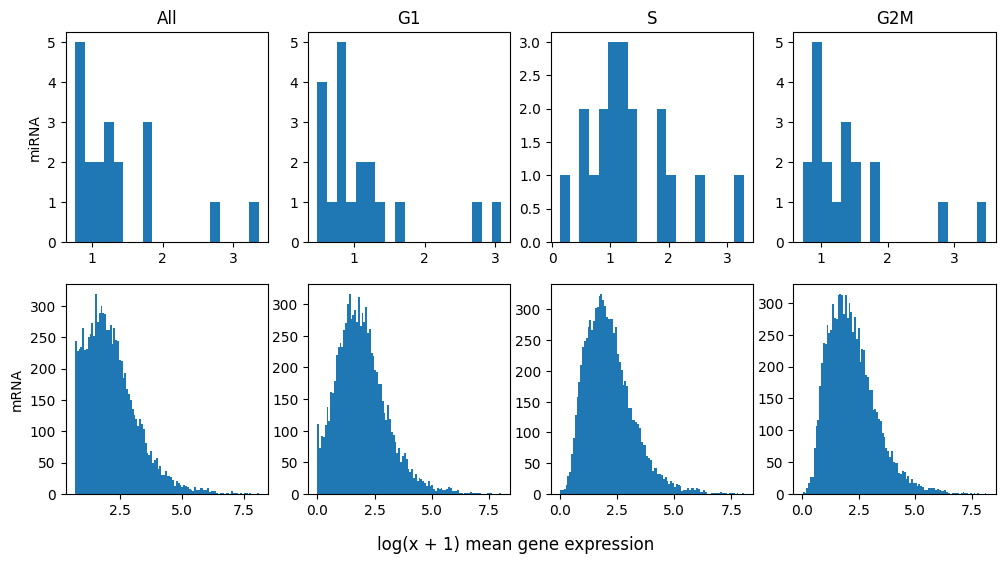

In [36]:
fig, axs = plt.subplots(2, 4, squeeze=False, figsize=(12, 6))
data_miRNA_list = [data_FIB_miRNA, data_FIB_G1_miRNA, data_FIB_S_miRNA, data_FIB_G2M_miRNA]
data_pcRNA_list = [data_FIB_pcRNA, data_FIB_G1_pcRNA, data_FIB_S_pcRNA, data_FIB_G2M_pcRNA]
for i, (data_miRNA, data_pcRNA) in enumerate(zip(data_miRNA_list, data_pcRNA_list)):
    axs[0, i].hist(np.log(data_miRNA.mean(axis=1) + 1), bins=19)
    axs[1, i].hist(np.log(data_pcRNA.mean(axis=1) + 1), bins=100)
axs[0, 0].set_ylabel("miRNA")
axs[1, 0].set_ylabel("mRNA")
phases = ["All", "G1", "S", "G2M"]
for j, phase in enumerate(phases):
    axs[0, j].set_title(phase)
fig.supxlabel("log(x + 1) mean gene expression")
plt.show()

### miRNA count distributions per phase

Many miRNA have very sparse counts, with a large proportion of zeros

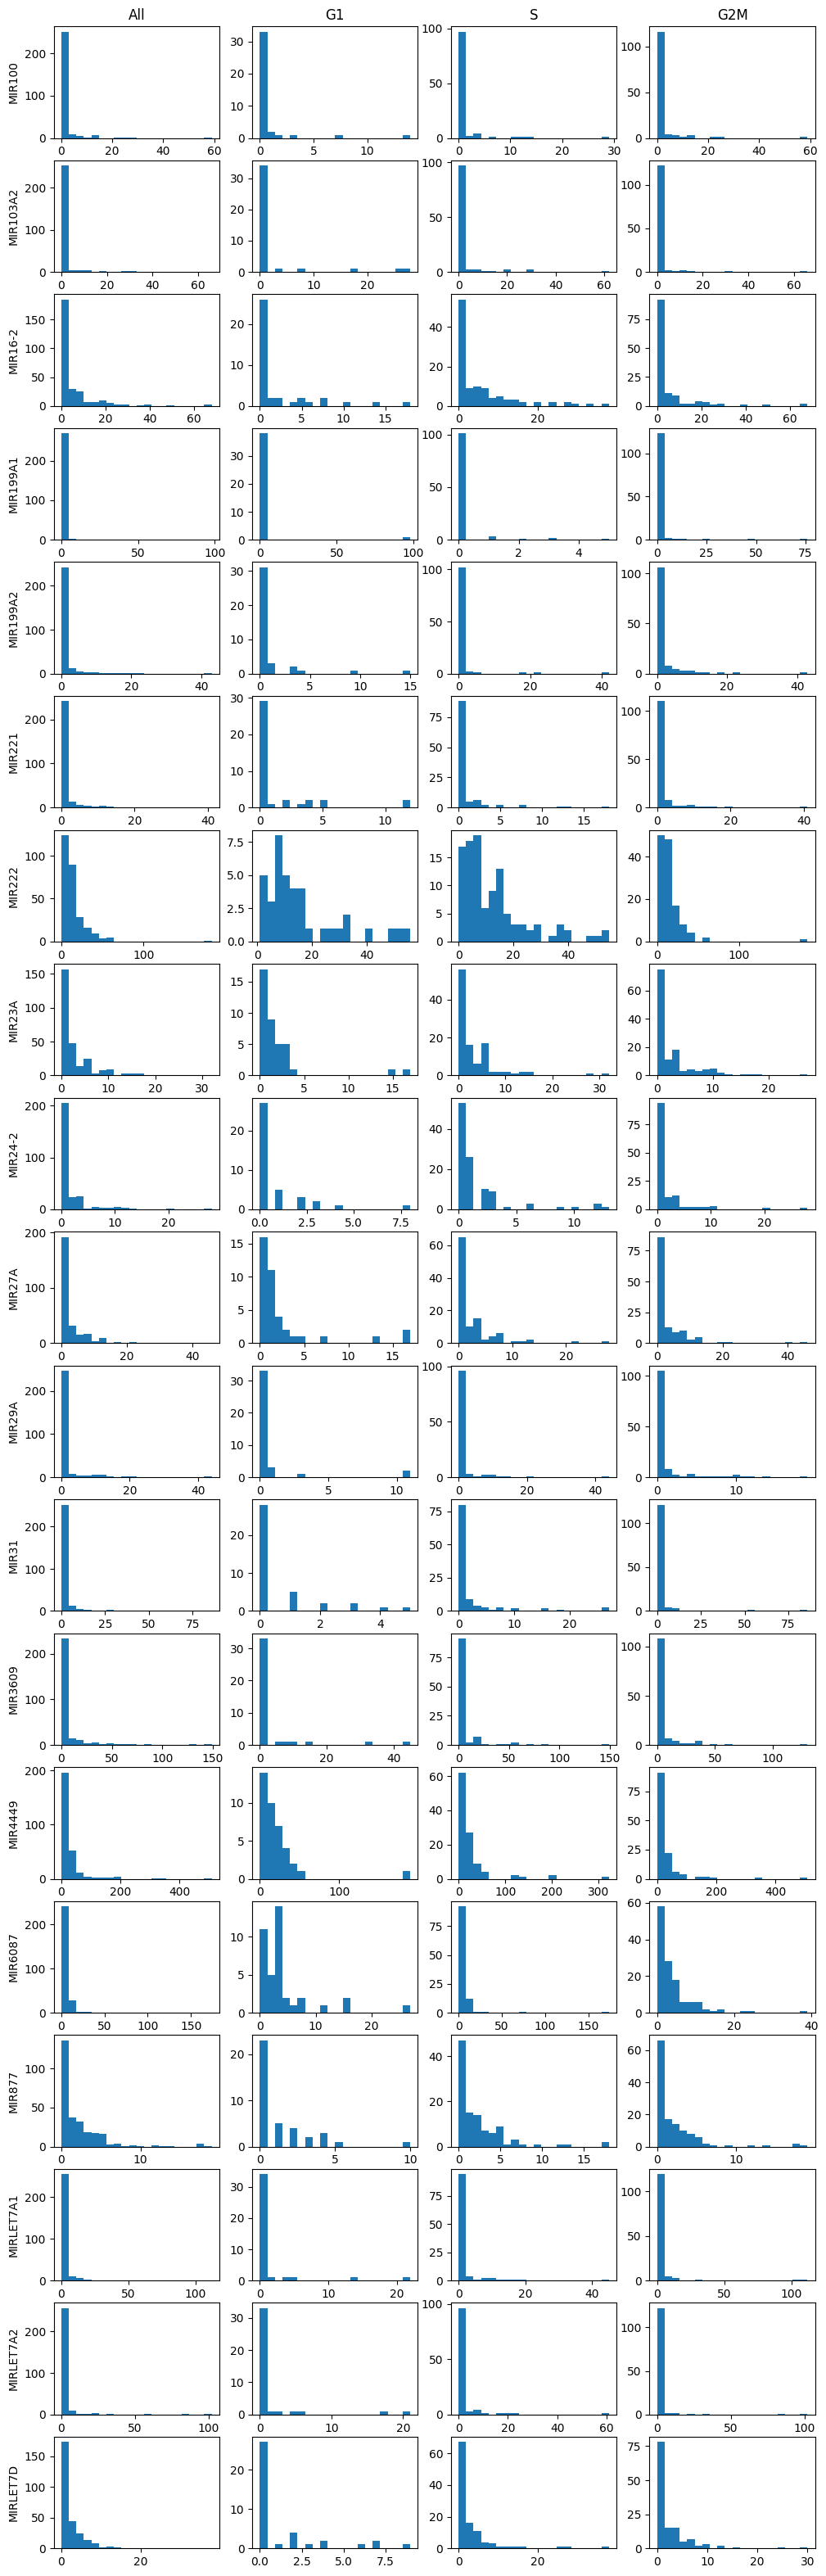

In [38]:
M = data_FIB_miRNA.shape[0]
fig, axs = plt.subplots(M, 4, squeeze=False, figsize=(12, 40))
data_miRNA_list = [data_FIB_miRNA, data_FIB_G1_miRNA, data_FIB_S_miRNA, data_FIB_G2M_miRNA]
for j, data_miRNA in enumerate(data_miRNA_list):
    for i in range(M):
        axs[i, j].hist(data_miRNA.iloc[i, :], bins=20)
        axs[i, 0].set_ylabel(data_miRNA.index[i])
phases = ["All", "G1", "S", "G2M"]
for j, phase in enumerate(phases):
    axs[0, j].set_title(phase)

## Analysis setup

In [41]:
def construct_dataset(mirna_sample, mrna_dataset, beta, resamples=1000):

    # size
    gene_pairs, cells = mrna_dataset.shape

    # construct paired count dataframe
    counts_df = pd.DataFrame(
        index = [f"Gene-pair-{i}" for i in range(gene_pairs)],
        columns = [f"Cell-{j}" for j in range(cells)]
    )

    # fill with pairs
    for i in range(gene_pairs):
        gene_i = mirna_sample
        gene_j = mrna_dataset.iloc[i]
        gene_pair_ij = list(zip(gene_i, gene_j))
        counts_df.iloc[i] = gene_pair_ij

    # construct dataset object
    data = Dataset()
    data.count_dataset = counts_df
    data.cells = cells
    data.gene_pairs = gene_pairs

    # settings
    data.resamples = resamples

    # set capture
    data.beta = beta

    return data

In [42]:
def model_free_independence_test(dataset, d, **kwargs):

    # Independent model free
    constraints = Constraint(
        moment_bounds=True,
        moment_matrices=True,
        factorization=True
    )
    opt_MF_ind = optimization.ModelFreeOptimization(dataset, d_bd=d, d_me=0, d_sd=d, constraints=constraints, printing=False, silent=True, **kwargs)
    opt_MF_ind.analyse_dataset()

    # extract results
    status = [solution['status'] for solution in opt_MF_ind.result_dict.values()]
    times  = [solution['time'] for solution in opt_MF_ind.result_dict.values()]
    cuts   = [solution['cuts'] for solution in opt_MF_ind.result_dict.values()]

    # collect
    data = {
        'status': status,
        'times': times,
        'cuts': cuts
    }

    return data

In [43]:
def model_free_interacting_test(dataset, d, **kwargs):

    # Interacting model free
    constraints = Constraint(
        moment_bounds=True,
        moment_matrices=True,
        factorization=False
    )
    opt_MF_int = optimization.ModelFreeOptimization(dataset, d_bd=d, d_me=0, d_sd=d, constraints=constraints, printing=False, silent=True, **kwargs)
    opt_MF_int.analyse_dataset()

    # extract results
    status = [solution['status'] for solution in opt_MF_int.result_dict.values()]
    times  = [solution['time'] for solution in opt_MF_int.result_dict.values()]
    cuts   = [solution['cuts'] for solution in opt_MF_int.result_dict.values()]
    correlation = [solution['correlation'] for solution in opt_MF_int.result_dict.values()]

    # convert None to NaN in correlations
    correlation = np.array(correlation, dtype=float)

    # collect
    data = {
        'status': status,
        'times': times,
        'cuts': cuts,
        'correlation': correlation
    }

    return data

In [44]:
def model_free_interacting_test_HAR(dataset, d, N, confidence=None, **kwargs):

    # confidence level: default to 95%
    if confidence is None:
        confidence = 0.95
    alpha = 1 - confidence

    # MF int HAR
    opt_har = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, N=N, **kwargs)
    opt_har.analyse_dataset()

    # extract results
    opt_correlation = []
    min_correlation = []
    max_correlation = []
    for i in range(dataset.gene_pairs):
        opt_correlation.append(opt_har.result_dict_optimization[i]['feasible_correlations'][0])
        har_correlations = opt_har.result_dict_HAR[i]['feasible_correlations']

        # exception leads to no results
        if har_correlations == None:
            min_correlation.append(np.nan)
            max_correlation.append(np.nan)
        else:
            # replace None with nan
            har_correlations = np.array(har_correlations, dtype=float)
            interval = np.nanquantile(har_correlations, [(alpha / 2), 1 - (alpha / 2)])
            min_correlation.append(interval[0])
            max_correlation.append(interval[1])

    # collect
    data = {
        'opt_correlation': opt_correlation,
        'min_correlation': min_correlation,
        'max_correlation': max_correlation
    }

    return data

In [45]:
def model_free_interacting_test_RND(dataset, d, N, confidence=None, **kwargs):

    # confidence level: default to 95%
    if confidence is None:
        confidence = 0.95
    alpha = 1 - confidence

    # MF int random linear objectives
    opt_rnd = optimization_MOSEK.MOSEKModelFreeInteracting(dataset, d, method_opt="random", N=N)
    opt_rnd.analyse_dataset()

    # extract results
    min_correlation = []
    max_correlation = []
    for i in range(dataset.gene_pairs):
        rnd_correlations = opt_rnd.result_dict_optimization[i]['feasible_correlations']

        # exception leads to no results
        if rnd_correlations == None:
            min_correlation.append(np.nan)
            max_correlation.append(np.nan)
        else:
            # replace None with nan
            rnd_correlations = np.array(rnd_correlations, dtype=float)
            interval = np.nanquantile(rnd_correlations, [(alpha / 2), 1 - (alpha / 2)])
            min_correlation.append(interval[0])
            max_correlation.append(interval[1])

    # collect
    data = {
        'min_correlation': min_correlation,
        'max_correlation': max_correlation
    }

    return data

In [46]:
def correlation_bootstrap_sample(sample, beta, confidence=None, resamples=None):

    # get sample size
    n = sample.shape[0]

    # get bootstrap size: default to sample size
    if resamples is None:
        resamples = n
    # confidence level: default to 95%
    if confidence is None:
        confidence = 0.95

    # initialize random generator
    rng = np.random.default_rng()

    # bootstrap to N x n x 2 array
    boot = rng.choice(sample, size=(resamples, n))

    # capture moments
    E_beta = np.mean(beta)
    E_beta2 = np.mean(beta**2)

    # compute correlations
    estimates = np.zeros(resamples)
    for i in range(resamples):

        b1 = boot[i, :, 0]
        b2 = boot[i, :, 1]

        # OB moments
        E_xy_OB = np.mean(b1 * b2)
        E_x_OB = np.mean(b1)
        E_y_OB = np.mean(b2)
        E_x2_OB = np.mean(b1**2)
        E_y2_OB = np.mean(b2**2)

        # OG moments
        E_xy_OG = E_xy_OB / E_beta2
        E_x_OG = E_x_OB / E_beta
        E_y_OG = E_y_OB / E_beta
        E_x2_OG = (1 / E_beta2)*E_x2_OB + (1 / E_beta)*E_x_OB - (1 / E_beta2)*E_x_OB
        E_y2_OG = (1 / E_beta2)*E_y2_OB + (1 / E_beta)*E_y_OB - (1 / E_beta2)*E_y_OB

        varx_OG = E_x2_OG - E_x_OG**2
        vary_OG = E_y2_OG - E_y_OG**2

        if varx_OG <= 0.0 or vary_OG <= 0.0:
            corr = np.nan
        else:
            corr = (E_xy_OG - E_x_OG*E_y_OG) / (np.sqrt(varx_OG) * np.sqrt(vary_OG))

        estimates[i] = corr

    # take quantiles
    alpha = 1 - confidence
    interval = np.nanquantile(estimates, [(alpha / 2), 1 - (alpha / 2)])

    # compute point estimate from original sample
    b1 = sample[:, 0]
    b2 = sample[:, 1]

    # OB moments
    E_xy_OB = np.mean(b1 * b2)
    E_x_OB = np.mean(b1)
    E_y_OB = np.mean(b2)
    E_x2_OB = np.mean(b1**2)
    E_y2_OB = np.mean(b2**2)

    # OG moments
    E_xy_OG = E_xy_OB / E_beta2
    E_x_OG = E_x_OB / E_beta
    E_y_OG = E_y_OB / E_beta
    E_x2_OG = (1 / E_beta2)*E_x2_OB + (1 / E_beta)*E_x_OB - (1 / E_beta2)*E_x_OB
    E_y2_OG = (1 / E_beta2)*E_y2_OB + (1 / E_beta)*E_y_OB - (1 / E_beta2)*E_y_OB

    varx_OG = E_x2_OG - E_x_OG**2
    vary_OG = E_y2_OG - E_y_OG**2

    if varx_OG <= 0.0 or vary_OG <= 0.0:
        corr = np.nan
    else:
        corr = (E_xy_OG - E_x_OG*E_y_OG) / (np.sqrt(varx_OG) * np.sqrt(vary_OG))

    # collect results
    result = np.array([
        corr,
        interval[0],
        interval[1]
    ])

    return result

In [47]:
def correlation_bootstrap_dataset(dataset, confidence=None, resamples=None):
    '''Bootstrap dataset correlations.'''

    # record results
    results = np.empty((dataset.gene_pairs, 3))
    
    # bootstrap
    for i in tqdm.tqdm(range(dataset.gene_pairs)):
        results[i, :] = correlation_bootstrap_sample(np.array([*dataset.count_dataset.iloc[i].values]), np.ones(dataset.cells), confidence, resamples)

    return results

In [48]:
def analytic_correlation_bootstrap_dataset(dataset, confidence=None, resamples=None):
    '''Bootstrap dataset correlations adjusted for capture efficiency.'''

    # record results
    results = np.empty((dataset.gene_pairs, 3))
    
    # bootstrap
    for i in tqdm.tqdm(range(dataset.gene_pairs)):
        results[i, :] = correlation_bootstrap_sample(np.array([*dataset.count_dataset.iloc[i].values]), dataset.beta, confidence, resamples)

    return results

## Errors

### None and NaN

Quantiles over correlations should use `np.nanquantile()` to ignore NaN values

However, does not work with None values so should consider changing to use NaN as default error value

In [61]:
a = np.array([1, 2, 3, 4, 5, 6, np.nan, np.nan])
np.quantile(a, [0.1, 0.9])

array([nan, nan])

In [62]:
a = np.array([1, 2, 3, 4, 5, 6, np.nan, np.nan])
np.nanquantile(a, [0, 1])

array([1., 6.])

In [63]:
a = np.array([1, 2, 3, 4, 5, 6, None, None])
try:
    np.nanquantile(a, [0, 1])
except Exception as e:
    print(e)

'<' not supported between instances of 'NoneType' and 'int'


In [64]:
b = [1, 2, 3, 4, 5, 6, None, None]
np.array(b, dtype=float)

array([ 1.,  2.,  3.,  4.,  5.,  6., nan, nan])

### Zero variance - undefined correlation

In some cases e.g. miRNA `MIR199A1` and phase `G1`, the combination of few cells (39) and low miRNA expression can lead to feasible values of 0 variance (see below) and so an undefined correlation value

In [65]:
# select miRNA
miRNA = "MIR199A1"

# settings
d = 3
confidence = 0.95
time_limit = 30
total_time_limit = 30
cut_limit = 100

# construct dataset of miRNA paired with mRNA
dataset_SDP = construct_dataset(data_FIB_G1_miRNA.loc[miRNA], data_FIB_G1_pcRNA.loc[mRNA], beta_FIB_G1)

# bootstrap
print("Bootstrap:")
dataset_SDP.confidence = confidence
dataset_SDP.bootstrap(d=d, tqdm_disable=False)

# Interacting model free
constraints = Constraint(
    moment_bounds=True,
    moment_matrices=True,
    factorization=False
)
opt_MF_int = optimization.ModelFreeOptimization(dataset_SDP, d_bd=d, d_me=0, d_sd=d, constraints=constraints, printing=False, silent=True, time_limit=time_limit, total_time_limit=total_time_limit, cut_limit=cut_limit)
opt_MF_int.analyse_dataset()

# extract results
status = [solution['status'] for solution in opt_MF_int.result_dict.values()]
times  = [solution['time'] for solution in opt_MF_int.result_dict.values()]
cuts   = [solution['cuts'] for solution in opt_MF_int.result_dict.values()]
correlation = [solution['correlation'] for solution in opt_MF_int.result_dict.values()]

# collect
data = {
    'status': status,
    'times': times,
    'cuts': cuts,
    'correlation': correlation
}

Bootstrap:


100%|██████████| 100/100 [00:04<00:00, 22.84it/s]


In [66]:
for i in range(10):

    powers = utils.compute_powers(2, d)

    i_xy = powers.index([1, 1])
    i_x  = powers.index([1, 0])
    i_y  = powers.index([0, 1])
    i_x2 = powers.index([2, 0])
    i_y2 = powers.index([0, 2])

    # extract feasible point
    var_dict = opt_MF_int.feasible_values_dict[i][-1]

    # collect moment values
    E_xy = var_dict[f'y[{i_xy}]']
    E_x  = var_dict[f'y[{i_x}]']
    E_y  = var_dict[f'y[{i_y}]']
    E_x2 = var_dict[f'y[{i_x2}]']
    E_y2 = var_dict[f'y[{i_y2}]']

    # compute statistics
    cov_xy = E_xy - E_x*E_y
    var_x = E_x2 - E_x**2
    var_y = E_y2 - E_y**2

    print(f"Cov {cov_xy} | Var miRNA {var_x} | Var pcRNA {var_y}")

print("...")

Cov 0.0 | Var miRNA 0.0 | Var pcRNA 8563.288381327317
Cov 0.0 | Var miRNA 0.0 | Var pcRNA 17702.213125952905
Cov 0.0 | Var miRNA 0.0 | Var pcRNA 16791.49718046126
Cov 0.0 | Var miRNA 0.0 | Var pcRNA 6824.396434196917
Cov 0.0 | Var miRNA 0.0 | Var pcRNA 8272.726092396017
Cov 0.0 | Var miRNA 0.0 | Var pcRNA 96198.61500952434
Cov 0.0 | Var miRNA 0.0 | Var pcRNA 14977.385482303867
Cov 0.0 | Var miRNA 0.0 | Var pcRNA 100594.06270283234
Cov 0.0 | Var miRNA 0.0 | Var pcRNA 46862.017102521466
Cov 0.0 | Var miRNA 0.0 | Var pcRNA 26385.05439304215
...


### Independent feasible but correlation interval doesn't contain 0

In [39]:
# select single gene pair
# run independence test and show feasible
# run hit and run
# look at feasible points & correlations: see if 0 cov & var coincide / how many correlations are defined

In [115]:
# select pairs
g = 0
miRNA = "MIR199A1"
mRNA = data_FIB_G1_pcRNA.index[g:(g+1)]

# settings
d = 3
confidence = 0.95
time_limit = 30
total_time_limit = 30
cut_limit = 100

# construct dataset of miRNA paired with mRNA
dataset_SDP = construct_dataset(data_FIB_G1_miRNA.loc[miRNA], data_FIB_G1_pcRNA.loc[mRNA], beta_FIB_G1)

# bootstrap
print("Bootstrap:")
dataset_SDP.confidence = confidence
dataset_SDP.bootstrap(d=d, tqdm_disable=False)

Bootstrap:


100%|██████████| 1/1 [00:00<00:00, 74.17it/s]


In [116]:
# Model free Independence test
constraints = Constraint(
    moment_bounds=True,
    moment_matrices=True,
    factorization=True
)
opt_MF_ind = optimization.ModelFreeOptimization(dataset_SDP, d_bd=d, d_me=0, d_sd=d, constraints=constraints, printing=False, silent=True, time_limit=time_limit, total_time_limit=total_time_limit, cut_limit=cut_limit)
opt_MF_ind.analyse_dataset()

100%|██████████| 1/1 [00:00<00:00, 10.79it/s]


In [117]:
# feasible under model free interacting test
opt_MF_ind.result_dict

{0: {'status': 'OPTIMAL',
  'time': 0.006000041961669922,
  'cuts': 1,
  'correlation': np.float64(0.0)}}

In [118]:
# Model free Interacting test
constraints = Constraint(
    moment_bounds=True,
    moment_matrices=True,
    factorization=False
)
opt_MF_int = optimization.ModelFreeOptimization(dataset_SDP, d_bd=d, d_me=0, d_sd=d, constraints=constraints, printing=False, silent=True, time_limit=time_limit, total_time_limit=total_time_limit, cut_limit=cut_limit)
opt_MF_int.analyse_dataset()

100%|██████████| 1/1 [00:00<00:00, 17.78it/s]


In [119]:
# correlation undefined
opt_MF_int.result_dict

{0: {'status': 'OPTIMAL',
  'time': 0.002000093460083008,
  'cuts': 3,
  'correlation': None}}

In [120]:
# settings
N = 10000
confidence = 0.95
alpha = 1 - confidence

# Hit and Run
opt_har = optimization_MOSEK.MOSEKModelFreeInteracting(dataset_SDP, d, N=N)
opt_har.analyse_dataset()

100%|██████████| 1/1 [00:08<00:00,  8.36s/it]


In [121]:
opt_har.result_dict_optimization[0]

{'feasible_points': [array([1.00000000e+00, 2.92471204e+01, 3.11016333e+01, 1.91123008e+03,
         1.39951190e+02, 2.35888289e+03, 1.90768054e+05, 4.14048522e+03,
         1.45470056e+04, 2.67697794e+05])],
 'feasible_correlations': [-0.6349804775509519]}

In [122]:
print(f"Initial optimization point correlation {opt_har.result_dict_optimization[0]['feasible_correlations'][0]}")
har_correlations = opt_har.result_dict_HAR[0]['feasible_correlations']

# exception leads to no results
if har_correlations == None:
    min_correlation = np.nan
    max_correlation = np.nan
else:
    # replace None with nan
    har_correlations = np.array(har_correlations, dtype=float)
    interval = np.nanquantile(har_correlations, [(alpha / 2), 1 - (alpha / 2)])
    min_correlation = interval[0]
    max_correlation = interval[1]
print(f"Hit and Run correlation interval ({min_correlation}, {max_correlation})")

Initial optimization point correlation -0.6349804775509519
Hit and Run correlation interval (-0.9747279327545421, -0.0020821006441958377)


In [125]:
np.isnan(har_correlations).sum()

np.int64(0)

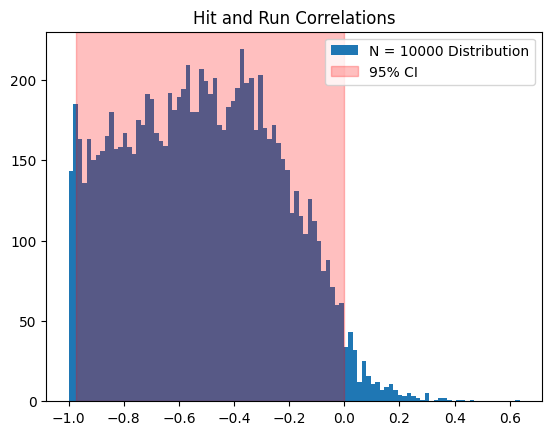

In [126]:
plt.hist(opt_har.result_dict_HAR[0]['feasible_correlations'], bins=100, label=f"N = {N} Distribution");
plt.axvspan(min_correlation, max_correlation, color="red", alpha=0.25, label="95% CI")
plt.title("Hit and Run Correlations")
plt.legend()
plt.show()

## Test run

In [83]:
# select mRNA
G = 100
mRNA = data_FIB_G1_pcRNA.index[:G]

# dataframe to store model free results
MF_independent_df = pd.DataFrame(
    index=mRNA
)
MF_interacting_df = pd.DataFrame(
    index=mRNA
)

In [ ]:
# select miRNA
miRNA = "MIR199A1"

# settings
d = 3
N = 1000
confidence = 0.95
time_limit = 30
total_time_limit = 30
cut_limit = 100

# get datasets
data_miRNA_list = [data_FIB_miRNA, data_FIB_G1_miRNA, data_FIB_S_miRNA, data_FIB_G2M_miRNA]
data_pcRNA_list = [data_FIB_pcRNA, data_FIB_G1_pcRNA, data_FIB_S_pcRNA, data_FIB_G2M_pcRNA]
beta_list = [beta_FIB, beta_FIB_G1, beta_FIB_S, beta_FIB_G2M]

# for each phase
for i, phase in enumerate(["All", "G1", "S", "G2M"]):

    # display day
    print(f"\nRunning {phase} phase")

    # construct dataset of miRNA paired with mRNA
    dataset_SDP = construct_dataset(data_miRNA_list[i].loc[miRNA], data_pcRNA_list[i].loc[mRNA], beta_list[i])

    # bootstrap
    print("Bootstrap:")
    dataset_SDP.confidence = confidence
    dataset_SDP.bootstrap(d=d, tqdm_disable=False)

    # independence test
    print("Model Free Independence")
    MF_ind = model_free_independence_test(dataset_SDP, d, time_limit=time_limit, total_time_limit=total_time_limit, cut_limit=cut_limit)

    # display results
    print(np.unique(MF_ind['status'], return_counts=True))

    # interacting tests
    print("Model Free Interacting")
    MF_int_cut = model_free_interacting_test(dataset_SDP, d, time_limit=time_limit, total_time_limit=total_time_limit, cut_limit=cut_limit)
    MF_int_har = model_free_interacting_test_HAR(dataset_SDP, d, N)
    MF_int_rnd = model_free_interacting_test_RND(dataset_SDP, d, N)

    # correlation bootstraps
    print("Correlation Bootstraps")
    observed_correlation = correlation_bootstrap_dataset(dataset_SDP, confidence=confidence)
    analytic_correlation = analytic_correlation_bootstrap_dataset(dataset_SDP, confidence=confidence)

    # store results on dataframe
    MF_independent_df[f'{miRNA}_{phase}_d{d}_c{int(100*confidence)}_status'] = MF_ind['status']

    MF_interacting_df[f'{miRNA}_{phase}_d{d}_c{int(100*confidence)}_status_cut'] = MF_int_cut['status']
    MF_interacting_df[f'{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_cut'] = MF_int_cut['correlation']

    MF_interacting_df[f'{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_MOSEK'] = MF_int_har['opt_correlation']
    MF_interacting_df[f'{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_HAR_min'] = MF_int_har['min_correlation']
    MF_interacting_df[f'{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_HAR_max'] = MF_int_har['max_correlation']
    MF_interacting_df[f'{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_RND_min'] = MF_int_rnd['min_correlation']
    MF_interacting_df[f'{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_RND_max'] = MF_int_rnd['max_correlation']

    MF_interacting_df[f'{miRNA}_{phase}_c{int(100*confidence)}_corr_OB'] = observed_correlation[:, 0]
    MF_interacting_df[f'{miRNA}_{phase}_c{int(100*confidence)}_corr_OB_min'] = observed_correlation[:, 1]
    MF_interacting_df[f'{miRNA}_{phase}_c{int(100*confidence)}_corr_OB_max'] = observed_correlation[:, 2]
    MF_interacting_df[f'{miRNA}_{phase}_c{int(100*confidence)}_corr_AL'] = analytic_correlation[:, 0]
    MF_interacting_df[f'{miRNA}_{phase}_c{int(100*confidence)}_corr_AL_min'] = analytic_correlation[:, 1]
    MF_interacting_df[f'{miRNA}_{phase}_c{int(100*confidence)}_corr_AL_max'] = analytic_correlation[:, 2]

    # save dataframe
    #MF_independent_df.to_csv("Results/independent_MF.csv")
    #MF_interacting_df.to_csv("Results/interacting_MF.csv")


Running All phase
Bootstrap:


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:02<00:00, 33.79it/s]


Model Free Independence


100%|██████████| 100/100 [00:22<00:00,  4.42it/s]


...

100%|██████████| 100/100 [00:04<00:00, 24.72it/s]


(array(['INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([23, 77]))
Model Free Interacting


100%|██████████| 100/100 [05:43<00:00,  3.44s/it]


Correlation Bootstraps


100%|██████████| 100/100 [00:00<00:00, 143.28it/s]



Running All phase
Bootstrap:


  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:03<00:00, 25.99it/s]


Model Free Independence


100%|██████████| 100/100 [00:04<00:00, 20.77it/s]


...

100%|██████████| 100/100 [00:04<00:00, 23.26it/s]


(array(['INFEASIBLE', 'OPTIMAL'], dtype='<U10'), array([23, 77]))
Model Free Interacting


100%|██████████| 100/100 [05:30<00:00,  3.31s/it]


Correlation Bootstraps


100%|██████████| 100/100 [00:00<00:00, 168.45it/s]


### Results

In [86]:
print(MF_independent_df.to_string())

         MIR199A1_All_d3_c95_status MIR199A1_G1_d3_c95_status MIR199A1_S_d3_c95_status MIR199A1_G2M_d3_c95_status
A4GALT                      OPTIMAL                   OPTIMAL               INFEASIBLE                    OPTIMAL
AAAS                        OPTIMAL                   OPTIMAL                  OPTIMAL                    OPTIMAL
AACS                        OPTIMAL                   OPTIMAL                  OPTIMAL                    OPTIMAL
AADAT                    INFEASIBLE                   OPTIMAL                  OPTIMAL                 INFEASIBLE
AAGAB                       OPTIMAL                   OPTIMAL                  OPTIMAL                    OPTIMAL
AAK1                        OPTIMAL                   OPTIMAL                  OPTIMAL                    OPTIMAL
AAMDC                    INFEASIBLE                   OPTIMAL                  OPTIMAL                    OPTIMAL
AAMP                        OPTIMAL                   OPTIMAL                  OPTIMAL  

In [87]:
print(MF_interacting_df.to_string())

         MIR199A1_All_d3_c95_status_cut  MIR199A1_All_d3_c95_corr_cut  MIR199A1_All_d3_c95_corr_MOSEK  MIR199A1_All_d3_c95_corr_HAR_min  MIR199A1_All_d3_c95_corr_HAR_max  MIR199A1_All_d3_c95_corr_RND_min  MIR199A1_All_d3_c95_corr_RND_max  MIR199A1_All_c95_corr_OB  MIR199A1_All_c95_corr_OB_min  MIR199A1_All_c95_corr_OB_max  MIR199A1_All_c95_corr_AL  MIR199A1_All_c95_corr_AL_min  MIR199A1_All_c95_corr_AL_max MIR199A1_G1_d3_c95_status_cut  MIR199A1_G1_d3_c95_corr_cut  MIR199A1_G1_d3_c95_corr_MOSEK  MIR199A1_G1_d3_c95_corr_HAR_min  MIR199A1_G1_d3_c95_corr_HAR_max  MIR199A1_G1_d3_c95_corr_RND_min  MIR199A1_G1_d3_c95_corr_RND_max  MIR199A1_G1_c95_corr_OB  MIR199A1_G1_c95_corr_OB_min  MIR199A1_G1_c95_corr_OB_max  MIR199A1_G1_c95_corr_AL  MIR199A1_G1_c95_corr_AL_min  MIR199A1_G1_c95_corr_AL_max MIR199A1_S_d3_c95_status_cut  MIR199A1_S_d3_c95_corr_cut  MIR199A1_S_d3_c95_corr_MOSEK  MIR199A1_S_d3_c95_corr_HAR_min  MIR199A1_S_d3_c95_corr_HAR_max  MIR199A1_S_d3_c95_corr_RND_min  MIR199A1_S_d3_c95_

# Plots

## Data Loading

In [88]:
# load data
MF_independent_df = pd.read_csv("Results/independent_MF.csv", index_col=0)
MF_interacting_df = pd.read_csv("Results/interacting_MF.csv", index_col=0)

In [89]:
MF_independent_df.head()

,MIR199A1_All_d3_c95_status,MIR199A1_G1_d3_c95_status,MIR199A1_S_d3_c95_status,MIR199A1_G2M_d3_c95_status
A4GALT,OPTIMAL,OPTIMAL,INFEASIBLE,OPTIMAL
AAAS,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL
AACS,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL
AADAT,INFEASIBLE,OPTIMAL,OPTIMAL,INFEASIBLE
AAGAB,OPTIMAL,OPTIMAL,OPTIMAL,OPTIMAL


In [90]:
MF_interacting_df.head()

,MIR199A1_All_d3_c95_status_cut,MIR199A1_All_d3_c95_corr_cut,MIR199A1_All_d3_c95_corr_MOSEK,MIR199A1_All_d3_c95_corr_HAR_min,MIR199A1_All_d3_c95_corr_HAR_max,MIR199A1_All_d3_c95_corr_RND_min,MIR199A1_All_d3_c95_corr_RND_max,MIR199A1_All_c95_corr_OB,MIR199A1_All_c95_corr_OB_min,MIR199A1_All_c95_corr_OB_max,...,MIR199A1_G2M_d3_c95_corr_HAR_min,MIR199A1_G2M_d3_c95_corr_HAR_max,MIR199A1_G2M_d3_c95_corr_RND_min,MIR199A1_G2M_d3_c95_corr_RND_max,MIR199A1_G2M_c95_corr_OB,MIR199A1_G2M_c95_corr_OB_min,MIR199A1_G2M_c95_corr_OB_max,MIR199A1_G2M_c95_corr_AL,MIR199A1_G2M_c95_corr_AL_min,MIR199A1_G2M_c95_corr_AL_max
A4GALT,OPTIMAL,-0.058652,-0.086215,-0.414394,0.007280,-1.0,1.000000,0.020094,-0.037403,0.242227,...,-0.931900,0.764666,-1.0,0.905440,0.066012,-0.056971,0.567008,0.054229,-0.102882,0.650282
AAAS,OPTIMAL,0.017863,-0.001135,-0.070089,0.184591,-1.0,1.000000,0.037544,-0.061904,0.232063,...,-0.255103,0.228330,-1.0,1.000000,0.097141,-0.099344,0.284049,0.068028,-0.156211,0.239907
AACS,OPTIMAL,-0.107069,-0.300040,-0.626474,-0.043120,-1.0,-0.999722,-0.045457,-0.068413,-0.014155,...,-0.953870,-0.171012,-1.0,-0.999957,-0.053273,-0.088991,0.059919,-0.088722,-0.149656,-0.040376
AADAT,OPTIMAL,-0.097870,-0.419871,-0.884687,-0.143536,-1.0,-0.682269,-0.041669,-0.062644,-0.025610,...,-0.970007,-0.285378,-1.0,-0.999955,-0.053954,-0.081441,-0.024032,-0.084469,-0.132844,-0.058857
AAGAB,OPTIMAL,-0.067432,-0.168900,-0.509851,-0.066700,-1.0,0.999995,0.003183,-0.053085,0.225337,...,-0.824524,0.014266,-1.0,1.000000,0.039044,-0.061544,0.300565,0.008766,-0.142883,0.282944


## Model Free Independence Test

In [91]:
# set colours for all plots
plot_colours = {
    "OPTIMAL": "green",
    "INFEASIBLE": "red",
    "CUT_LIMIT": "blue",
    "TIME_LIMIT": "orange",
    "TOTAL_TIME_LIMIT": "pink",
    "NUMERIC": "black"
}

# set display names for status codes
display_names = {
    "OPTIMAL": "FEASIBLE",
    "INFEASIBLE": "INFEASIBLE",
    "CUT_LIMIT": "CUT_LIMIT",
    "TIME_LIMIT": "TIME_LIMIT",
    "TOTAL_TIME_LIMIT": "TOTAL_TIME_LIMIT",
    "NUMERIC": "NUMERIC"
}

### Interaction frequency

In [92]:
def status_pie_chart(dataframe, d, c, figsize=(12, 6)):

    # subplots
    m, n = 2, 3
    fig, axs = plt.subplots(m, n, figsize=figsize)

    phases = ["G1", "S", "G2M", "All"]

    # for each phase
    for k, phase in enumerate(phases):
        
        # select subplot
        i = k // n
        j = k % n

        # get data
        status_list = dataframe[f'MIR199A1_{phase}_d{d}_c{c}_status']
        status, counts = np.unique(status_list, return_counts=True)
        colors=[plot_colours[name] for name in status]

        # plot
        wedges, texts = axs[i, j].pie(
            counts,
            labels=[f"{round(100 * count / dataframe.shape[0], 1)}%" for count in counts],
            colors=colors,
            startangle=90,
            counterclock=False,
            rotatelabels=False
        )
        axs[i, j].set_title(phase)
        for text, color in zip(texts, colors):
            text.set_color(color)   
            
    # text legend
    axs[m - 1, n - 1].axis('off')
    axs[m - 1, n - 2].axis('off')
    axs[m - 1, n - 1].text(0.2, 0.8, f"d = {d}, c = {c}%", fontsize=15)
    k = 0
    for name, colour in plot_colours.items():
        axs[m - 1, n - 1].text(0.3, 0.7 - k*0.1, display_names[name], fontsize=15, color=colour)
        k+=1

    # title
    plt.suptitle(f"Model Free Independence test: Status (%) per phase")
    plt.tight_layout()
    plt.show()

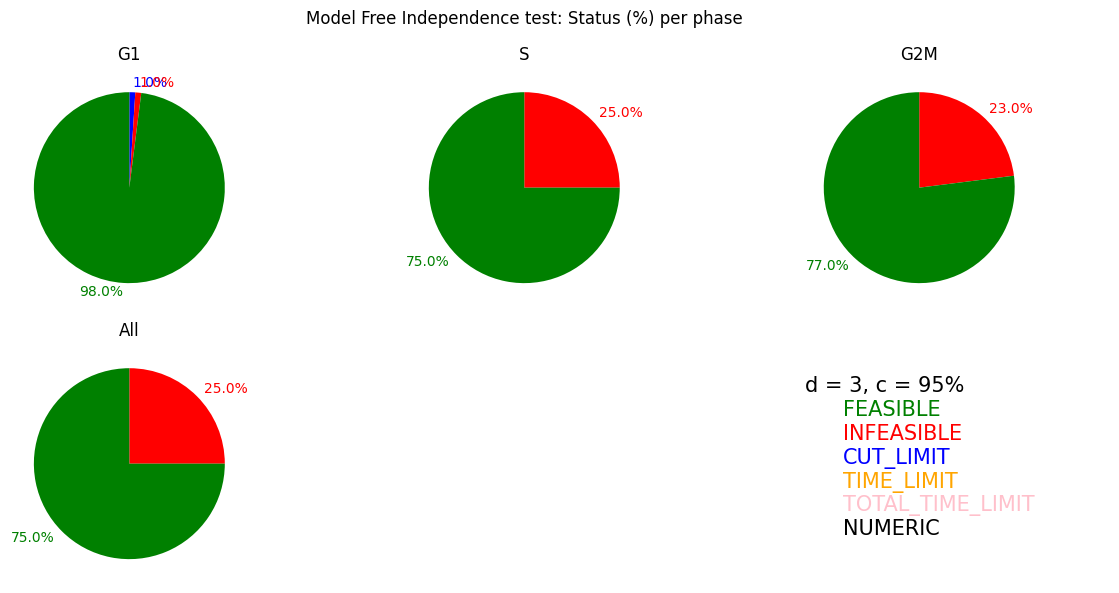

In [93]:
status_pie_chart(MF_independent_df, 3, 95)

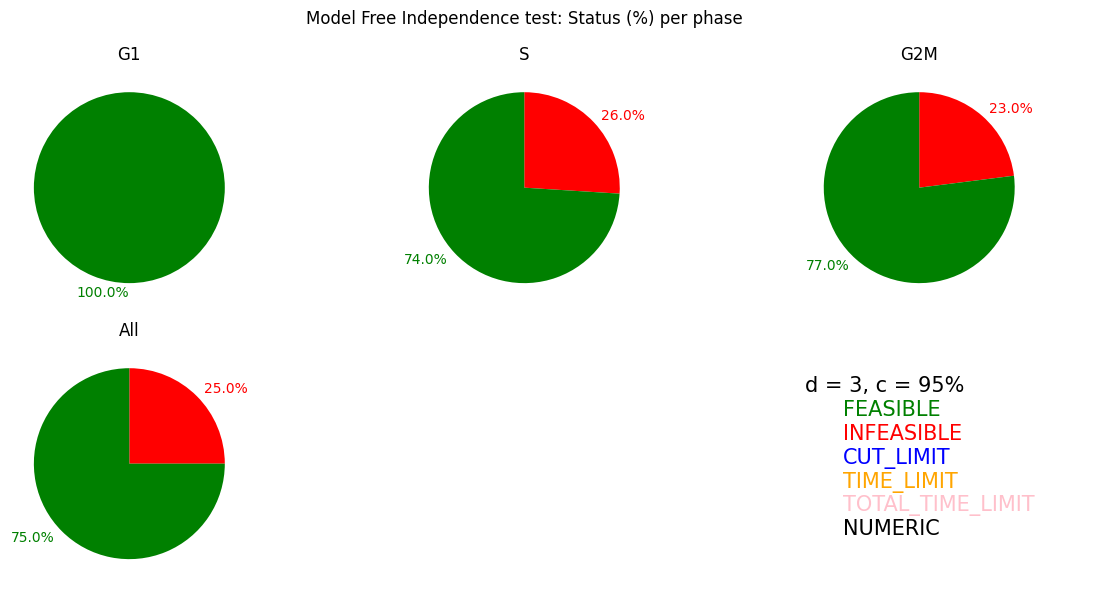

In [20]:
status_pie_chart(MF_independent_df, 3, 95)

### Interaction changes

In [94]:
import plotly.express as px

In [95]:
def add_clr_constructor(phase):
    
    def add_clr(row):
        status = row[f'MIR199A1_{phase}_d3_c95_status']
        if status == "OPTIMAL":
            return 0
        elif status == "INFEASIBLE":
            return 1
        else:
            return 2

    return add_clr    

In [96]:
phases = ["All", "G1", "S", "G2M"]
columns = [f"MIR199A1_{phase}_d3_c95_status" for phase in phases]
labels = {col: phase for col, phase in zip(columns, phases)}
df = MF_independent_df[columns]
df['clr'] = df.apply(add_clr_constructor("All"), axis=1)

fig = px.parallel_categories(df, dimensions=columns, labels=labels, color='clr', color_continuous_scale=px.colors.sequential.Jet)
font_dict = {
    'family': 'Calbiri',
    'size': 14,
    'color': 'black',
    'shadow': ''
}
fig.update_layout(font=font_dict)

In [23]:
phases = ["All", "G1", "S", "G2M"]
columns = [f"MIR199A1_{phase}_d3_c95_status" for phase in phases]
labels = {col: phase for col, phase in zip(columns, phases)}
df = MF_independent_df[columns]
df['clr'] = df.apply(add_clr_constructor("All"), axis=1)

fig = px.parallel_categories(df, dimensions=columns, labels=labels, color='clr', color_continuous_scale=px.colors.sequential.Jet)
font_dict = {
    'family': 'Calbiri',
    'size': 14,
    'color': 'black',
    'shadow': ''
}
fig.update_layout(font=font_dict)

In [97]:
phases = ["G1", "S", "G2M"]
columns = [f"MIR199A1_{phase}_d3_c95_status" for phase in phases]
labels = {col: phase for col, phase in zip(columns, phases)}
df = MF_independent_df[columns]
df['clr'] = df.apply(add_clr_constructor("G1"), axis=1)

fig = px.parallel_categories(df, dimensions=columns, labels=labels, color='clr', color_continuous_scale=px.colors.sequential.Magma)
font_dict = {
    'family': 'Calbiri',
    'size': 14,
    'color': 'black',
    'shadow': ''
}
fig.update_layout(font=font_dict)

In [24]:
phases = ["G1", "S", "G2M"]
columns = [f"MIR199A1_{phase}_d3_c95_status" for phase in phases]
labels = {col: phase for col, phase in zip(columns, phases)}
df = MF_independent_df[columns]
df['clr'] = df.apply(add_clr_constructor("G1"), axis=1)

fig = px.parallel_categories(df, dimensions=columns, labels=labels, color='clr', color_continuous_scale=px.colors.sequential.Magma)
font_dict = {
    'family': 'Calbiri',
    'size': 14,
    'color': 'black',
    'shadow': ''
}
fig.update_layout(font=font_dict)

### Interaction - Expression relationship

In [98]:
def expression_by_status_histogram(dataframe, d, c, figsize=(12, 6)):

    # subplots
    m, n = 2, 3
    fig, axs = plt.subplots(m, n, figsize=figsize)

    phases = ["G1", "S", "G2M", "All"]
    data_miRNA_list = [data_FIB_G1_miRNA, data_FIB_S_miRNA, data_FIB_G2M_miRNA, data_FIB_miRNA]
    data_pcRNA_list = [data_FIB_G1_pcRNA, data_FIB_S_pcRNA, data_FIB_G2M_pcRNA, data_FIB_pcRNA]
    miRNA = "MIR199A1"
    mRNA = data_FIB_pcRNA.index[:100]

    # for each phase
    for k, phase in enumerate(phases):
        
        # select subplot
        i = k // n
        j = k % n

        # get data
        mean_expression = np.log(data_pcRNA_list[k].loc[mRNA].mean(axis=1) + 1)
        status = dataframe[f'MIR199A1_{phase}_d{d}_c{c}_status']
        status_names = np.unique(status)

        # plot
        status_order = ["OPTIMAL", "CUT_LIMIT", "TIME_LIMIT", "TOTAL_TIME_LIMIT", "NUMERIC", "INFEASIBLE"]
        for name in status_order:
            mean_expression_status = mean_expression.loc[status == name]
            L = len(mean_expression_status)
            if L == 0: continue
            bins = int(np.sqrt(L))
            axs[i, j].hist(
                mean_expression_status,
                bins=bins,
                alpha=0.75,
                label=f"{display_names[name]} ({round(100 * len(mean_expression_status) / dataframe.shape[0], 1)}%)",
                color=plot_colours[name]
            )
        axs[i, j].set_title(phase)
        axs[i, j].set_xlabel("Observed mRNA mean expression")
        axs[i, j].set_ylabel("Frequency")
        axs[i, j].legend()

        # get data
        miRNA_mean_expression = np.log(data_miRNA_list[k].loc[miRNA].mean() + 1)
        axs[m - 1, n - 2].text(0.3, 0.7 - k*0.1, f"Phase {phase}: {round(miRNA_mean_expression, 2)}", fontsize=15, color="black")

    # text legend
    axs[m - 1, n - 1].axis('off')
    axs[m - 1, n - 2].axis('off')
    axs[m - 1, n - 1].text(0.2, 0.8, f"d = {d}, c = {c}%", fontsize=15)
    axs[m - 1, n - 2].text(0, 0.8, f"Observed miRNA mean expression", fontsize=15)
    k = 0
    for name, colour in plot_colours.items():
        axs[m - 1, n - 1].text(0.3, 0.7 - k*0.1, display_names[name], fontsize=15, color=colour)
        k+=1

    # title
    plt.suptitle(f"Model Free Independence Test: Observed mean expression (log(x + 1)) per status (per phase)")
    plt.tight_layout()
    plt.show()

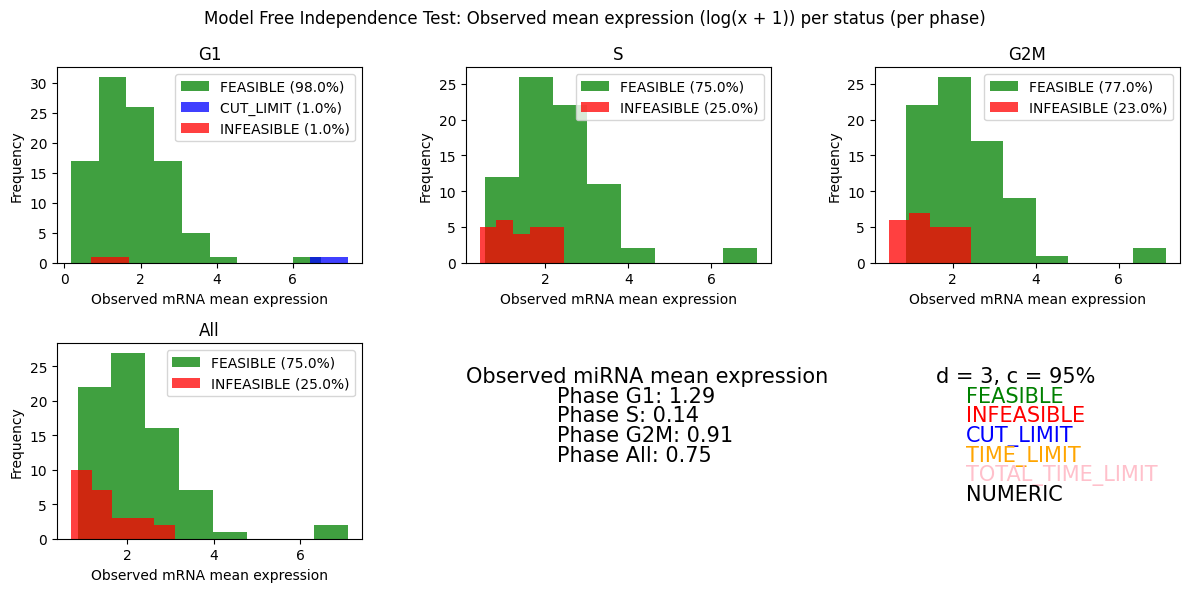

In [99]:
expression_by_status_histogram(MF_independent_df, 3, 95)

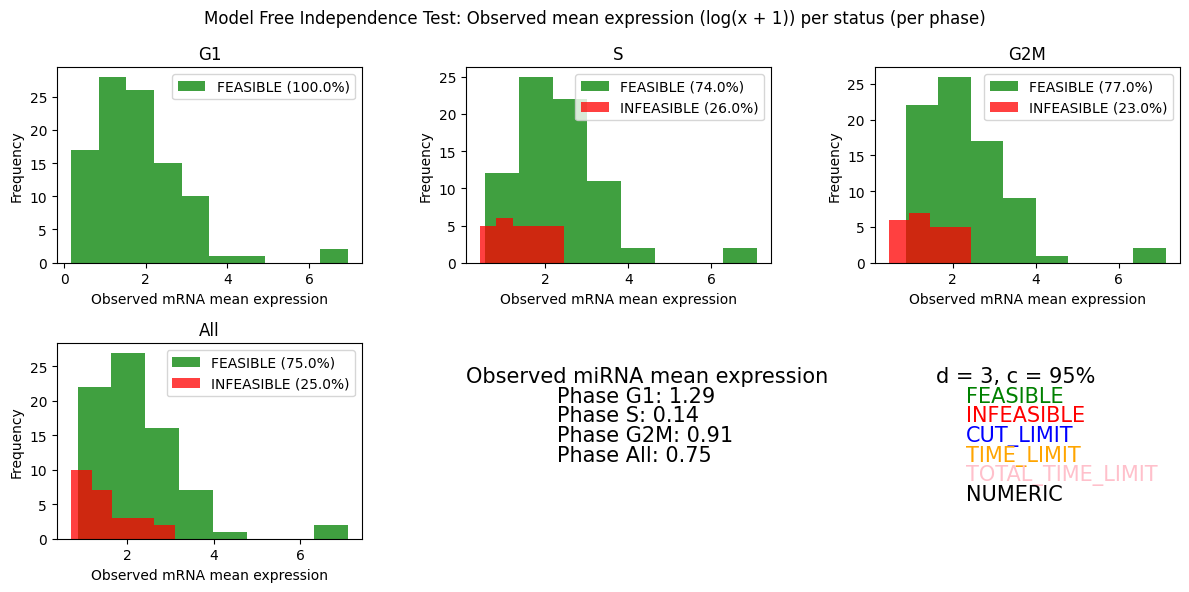

In [26]:
expression_by_status_histogram(MF_independent_df, 3, 95)

## Model Free Interacting test & Correlations

### Intervals per (miRNA, mRNA) pair

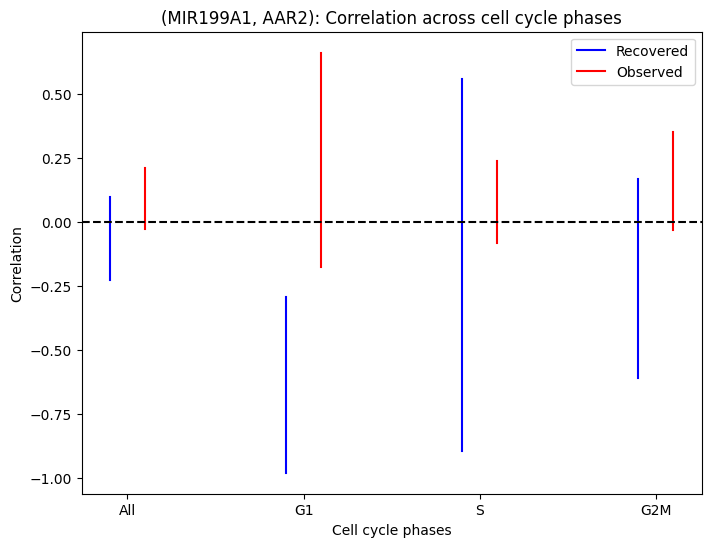

In [53]:
g = 8
d = 3
c = 95
miRNA = "MIR199A1"
mRNA_name = mRNA[g]

fig, axs = plt.subplots(figsize=(8, 6))
phases = ["All", "G1", "S", "G2M"]

for i, phase in enumerate(phases):
    axs.plot(
        [i - 0.1] * 2,
        [
            MF_interacting_df.loc[mRNA_name, f"{miRNA}_{phase}_d{d}_c{c}_corr_HAR_min"],
            MF_interacting_df.loc[mRNA_name, f"{miRNA}_{phase}_d{d}_c{c}_corr_HAR_max"]
        ],
        color="blue",
        label="Recovered" if i == 0 else None
    )
    axs.plot(
        [i + 0.1] * 2,
        [
            MF_interacting_df.loc[mRNA_name, f"{miRNA}_{phase}_c{c}_corr_OB_min"],
            MF_interacting_df.loc[mRNA_name, f"{miRNA}_{phase}_c{c}_corr_OB_max"]
        ],
        color="red",
        label="Observed" if i == 0 else None
    )

axs.axhline(0, linestyle="--", color="black")
axs.set_xticks(range(4), labels=phases)
axs.set_xlabel("Cell cycle phases")
axs.set_ylabel("Correlation")
axs.set_title(f"({miRNA}, {mRNA_name}): Correlation across cell cycle phases")
axs.legend()
plt.show()

#### Strange results

In [59]:
MF_interacting_df.loc[mRNA_name, f"{miRNA}_G1_d{d}_c{c}_corr_RND_min"]

np.float64(nan)

Q: why does G1 HAR correlation interval not contain 0 if feasible under model free independence test?
- AL interval does
- RND interval nan

Maybe tails cutoff?

Probably should only look at intervals for pairs that are infeasible under independence test?

### Point correlation scatters

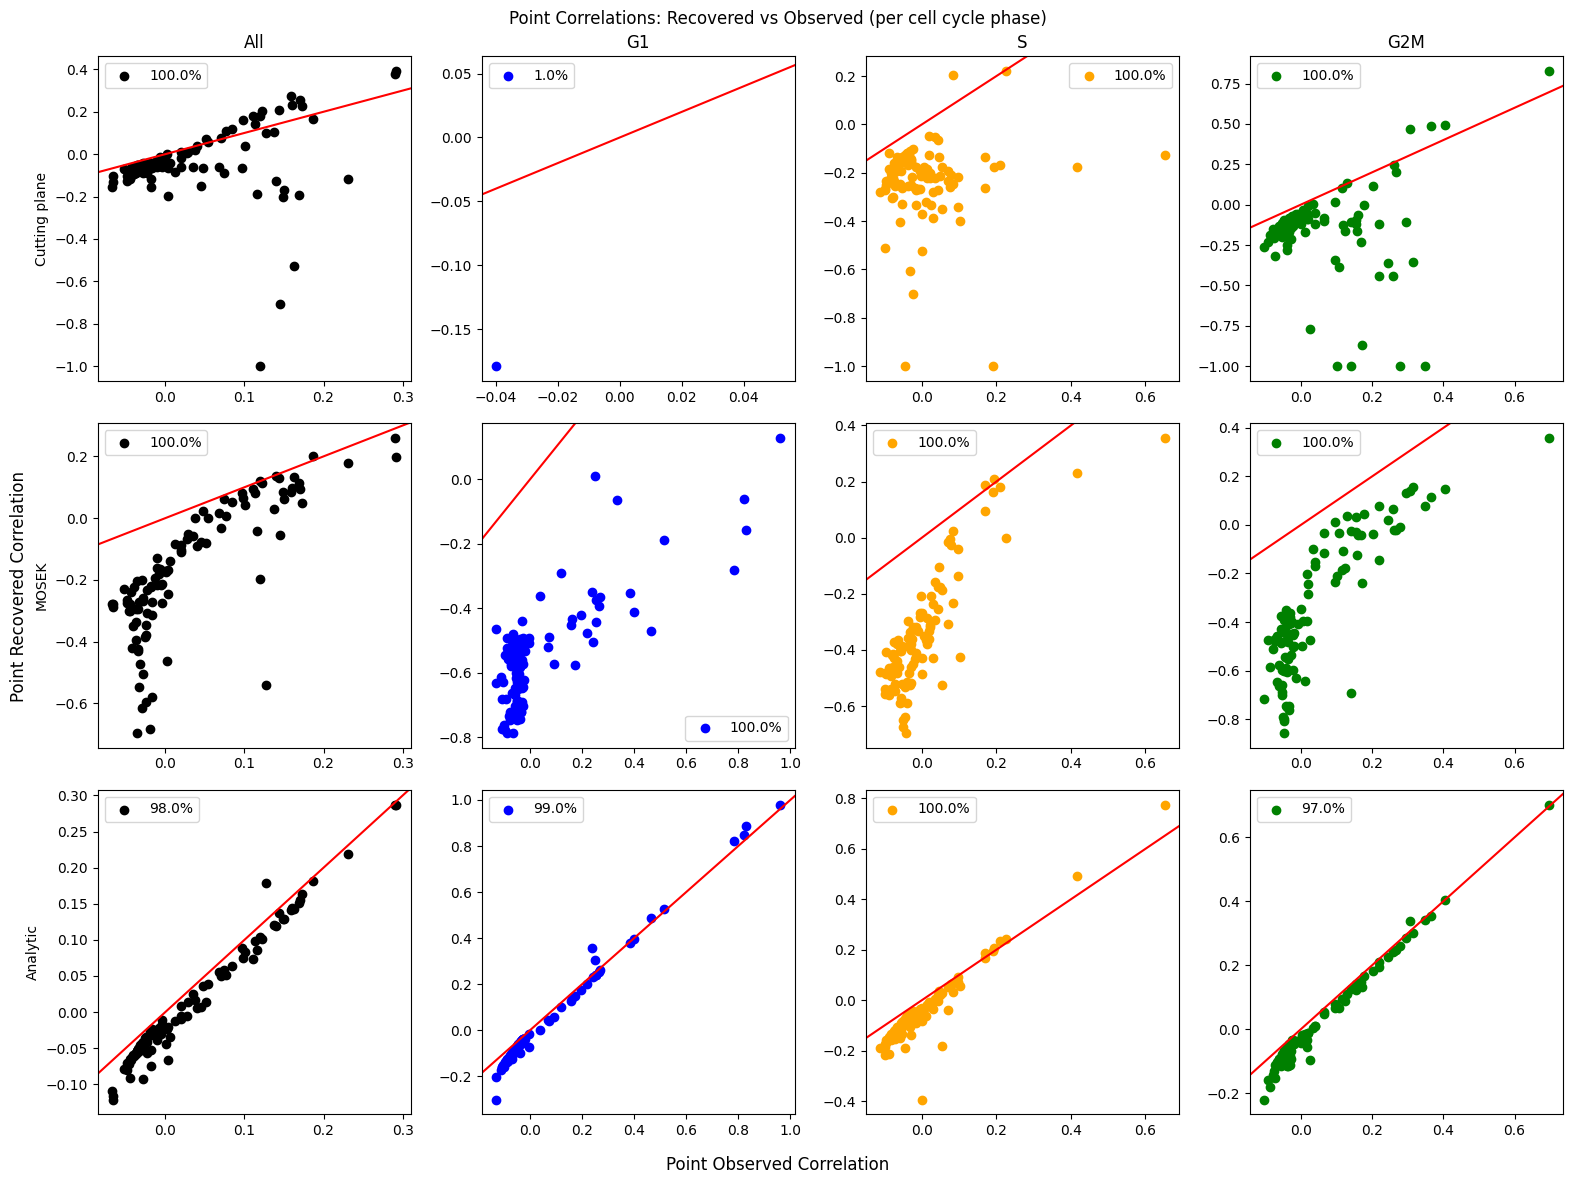

In [100]:
fig, axs = plt.subplots(3, 4, figsize=(16, 12))
colours = ["black", "blue", "orange", "green"]
phases = ["All", "G1", "S", "G2M"]
d = 3
c = 95
for j, (phase, colour) in enumerate(zip(phases, colours)):

    # observed
    corr_OB = MF_interacting_df[f"{miRNA}_{phase}_c{c}_corr_OB"]
    m = np.mean(corr_OB)

    # cutting plane
    corr_cut = MF_interacting_df[f"{miRNA}_{phase}_d{d}_c{c}_corr_cut"]
    axs[0, j].scatter(
        corr_OB,
        corr_cut,
        color=colour,
        label=f"{round(100 * len(corr_cut.dropna()) / len(corr_OB), 2)}%"
    )

    # MOSEK
    corr_MOSEK = MF_interacting_df[f"{miRNA}_{phase}_d{d}_c{c}_corr_MOSEK"]
    axs[1, j].scatter(
        corr_OB,
        corr_MOSEK,
        color=colour,
        label=f"{round(100 * len(corr_MOSEK.dropna()) / len(corr_OB), 2)}%"
    )

    # Analytic
    corr_AL = MF_interacting_df[f"{miRNA}_{phase}_c{c}_corr_AL"]
    axs[2, j].scatter(
        corr_OB,
        corr_AL,
        color=colour,
        label=f"{round(100 * len(corr_AL.dropna()) / len(corr_OB), 2)}%"
    )

    for i in range(3):
        axs[i, j].axline([m, m], [m + 0.01, m + 0.01], color="red")
        axs[i, j].legend()

axs[0, 0].set_title("All")
axs[0, 1].set_title("G1")
axs[0, 2].set_title("S")
axs[0, 3].set_title("G2M")

axs[0, 0].set_ylabel("Cutting plane")
axs[1, 0].set_ylabel("MOSEK")
axs[2, 0].set_ylabel("Analytic")

fig.supxlabel("Point Observed Correlation")
fig.supylabel("Point Recovered Correlation")
fig.suptitle("Point Correlations: Recovered vs Observed (per cell cycle phase)")

plt.tight_layout()
plt.show()

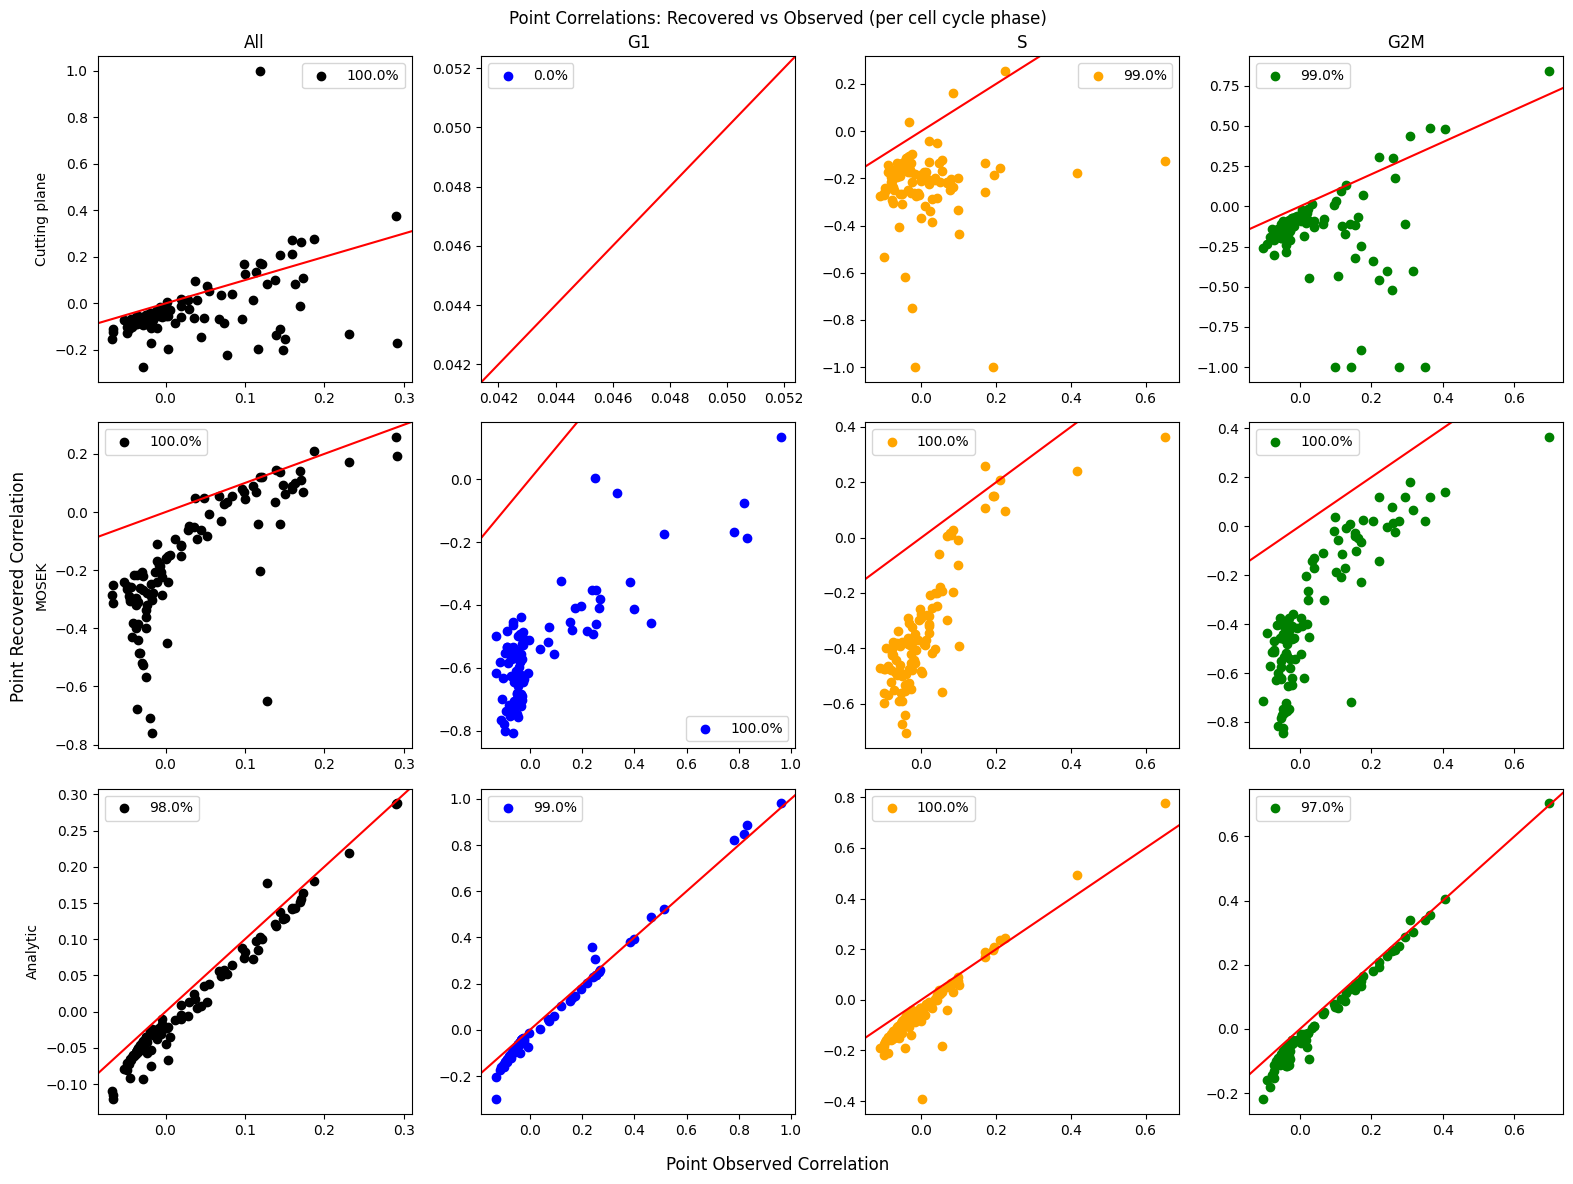

### Interval correlation scatters

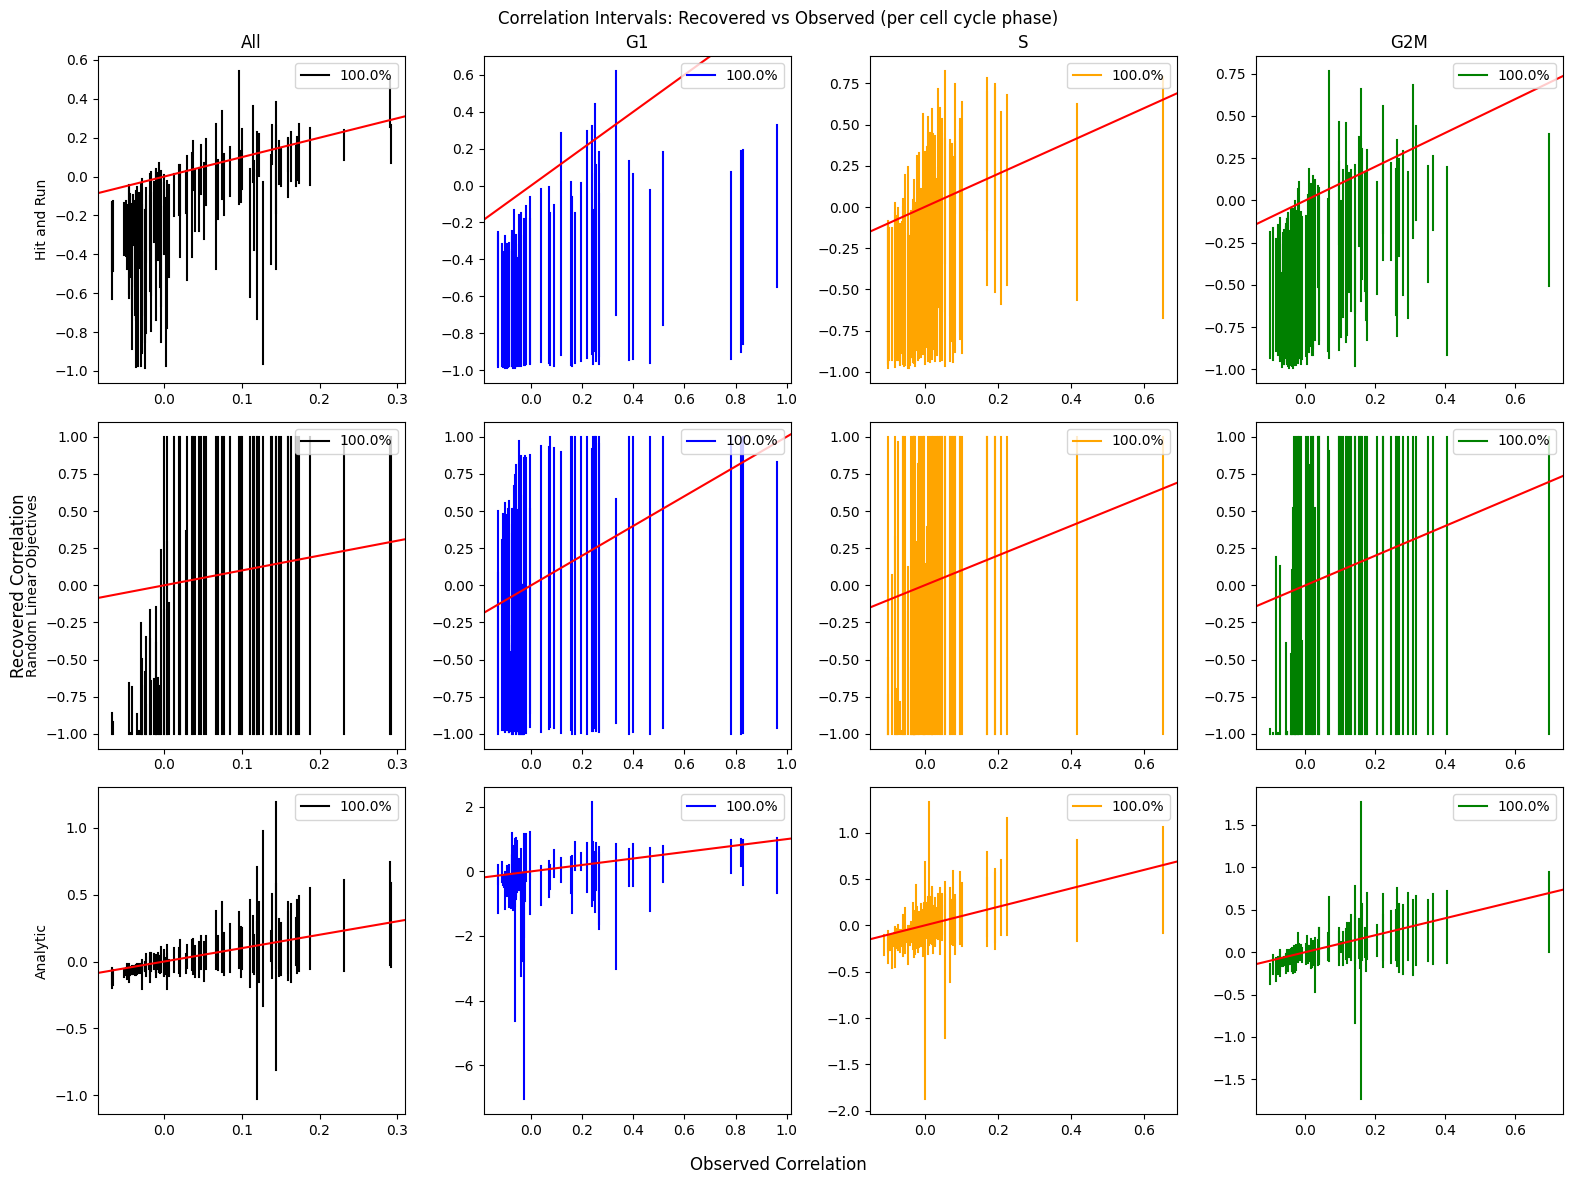

In [101]:
fig, axs = plt.subplots(3, 4, figsize=(16, 12))
colours = ["black", "blue", "orange", "green"]
phases = ["All", "G1", "S", "G2M"]
d = 3
c = 95
for j, (phase, colour) in enumerate(zip(phases, colours)):

    # observed
    corr_OB = MF_interacting_df[f"{miRNA}_{phase}_c{c}_corr_OB"]
    m = np.mean(corr_OB)

    # Hit and Run
    HAR_min = MF_interacting_df[f"{miRNA}_{phase}_d{d}_c{c}_corr_HAR_min"]
    HAR_max = MF_interacting_df[f"{miRNA}_{phase}_d{d}_c{c}_corr_HAR_max"]
    for k, (ob, lb, ub) in enumerate(zip(corr_OB, HAR_min, HAR_max)):
        axs[0, j].plot(
            [ob, ob],
            [lb, ub],
            color=colour,
            label=None
        )
    axs[0, j].plot(
        [None, None],
        [None, None],
        color=colour,
        label=f"{round(100 * len(HAR_min.dropna()) / len(corr_OB), 2)}%"
    )

    # Random Linear Objectives
    RND_min = MF_interacting_df[f"{miRNA}_{phase}_d{d}_c{c}_corr_RND_min"]
    RND_max = MF_interacting_df[f"{miRNA}_{phase}_d{d}_c{c}_corr_RND_max"]
    for k, (ob, lb, ub) in enumerate(zip(corr_OB, RND_min, RND_max)):
        axs[1, j].plot(
            [ob, ob],
            [lb, ub],
            color=colour,
            label=None
        )
    axs[1, j].plot(
        [None, None],
        [None, None],
        color=colour,
        label=f"{round(100 * len(RND_min.dropna()) / len(corr_OB), 2)}%"
    )

    # Analytic
    AL_min = MF_interacting_df[f"{miRNA}_{phase}_c{c}_corr_AL_min"]
    AL_max = MF_interacting_df[f"{miRNA}_{phase}_c{c}_corr_AL_max"]
    for k, (ob, lb, ub) in enumerate(zip(corr_OB, AL_min, AL_max)):
        axs[2, j].plot(
            [ob, ob],
            [lb, ub],
            color=colour,
            label=None
        )
    axs[2, j].plot(
        [None, None],
        [None, None],
        color=colour,
        label=f"{round(100 * len(AL_min.dropna()) / len(corr_OB), 2)}%"
    )

    for i in range(3):
        axs[i, j].axline([m, m], [m + 0.01, m + 0.01], color="red")
        axs[i, j].legend(loc="upper right")

axs[0, 0].set_title("All")
axs[0, 1].set_title("G1")
axs[0, 2].set_title("S")
axs[0, 3].set_title("G2M")

axs[0, 0].set_ylabel("Hit and Run")
axs[1, 0].set_ylabel("Random Linear Objectives")
axs[2, 0].set_ylabel("Analytic")

fig.supxlabel("Observed Correlation")
fig.supylabel("Recovered Correlation")
fig.suptitle("Correlation Intervals: Recovered vs Observed (per cell cycle phase)")

plt.tight_layout()
plt.show()

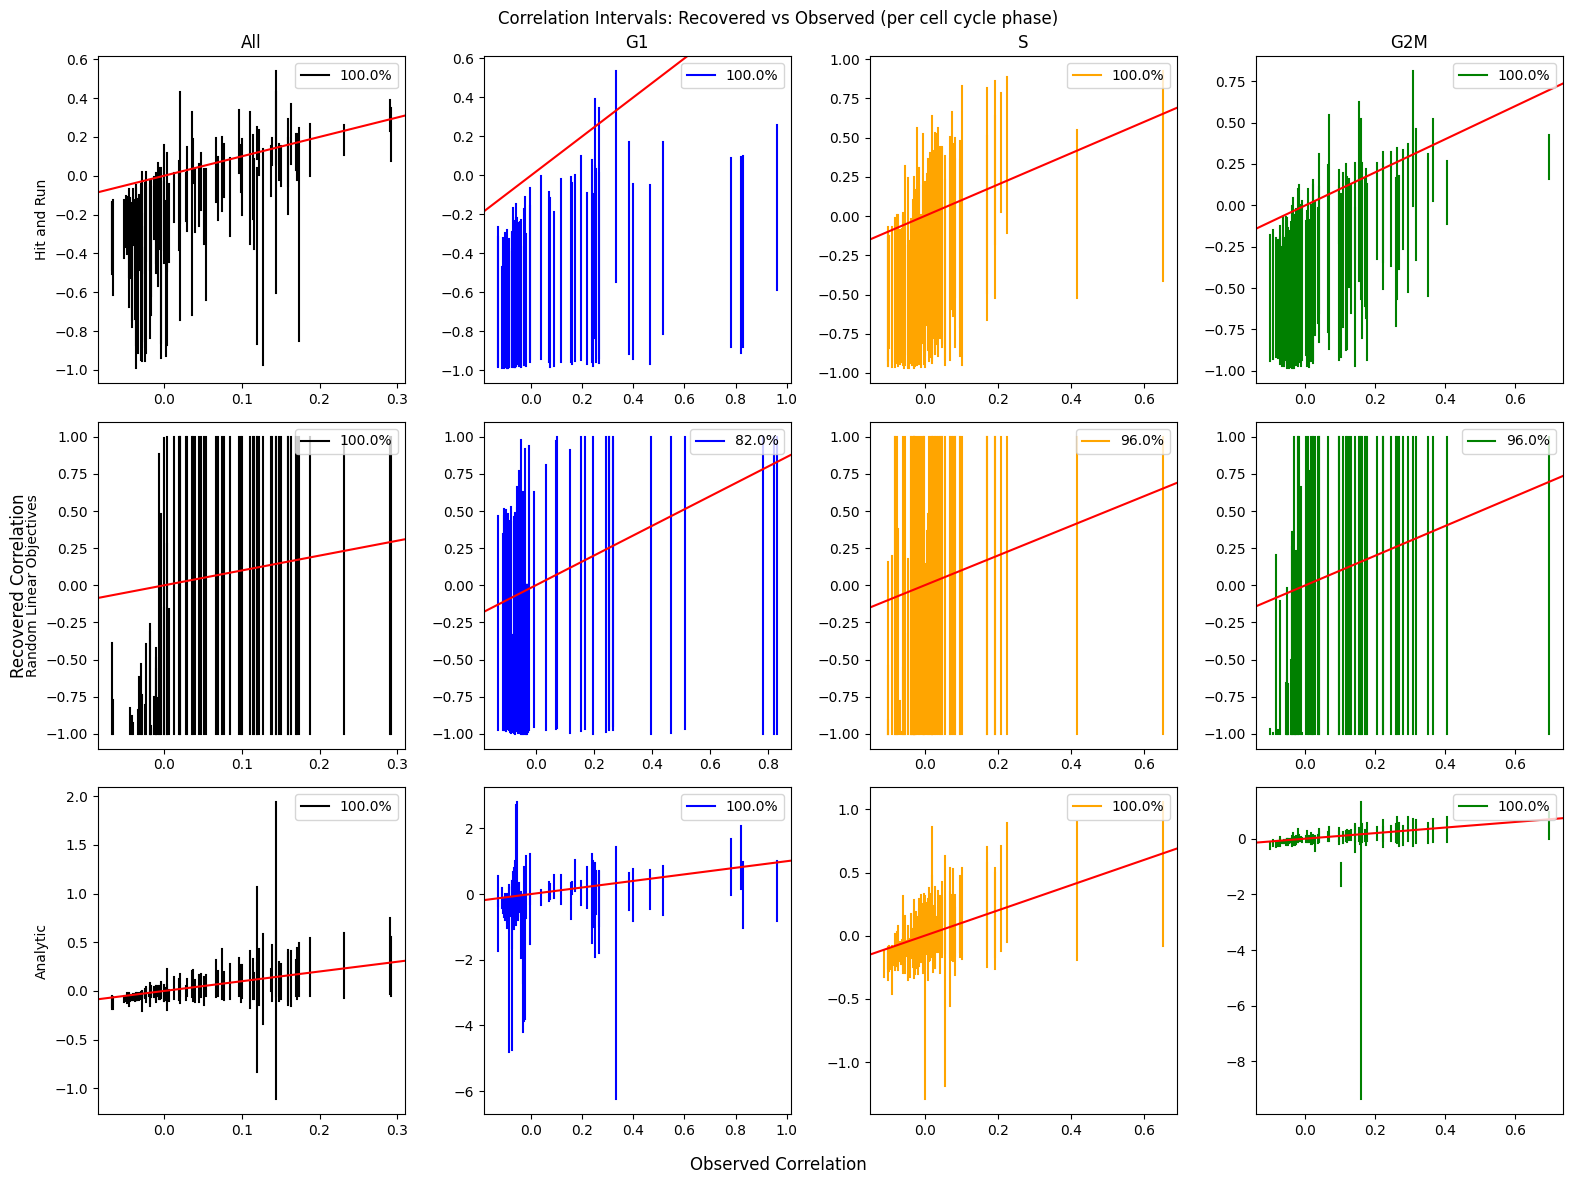

### Testing

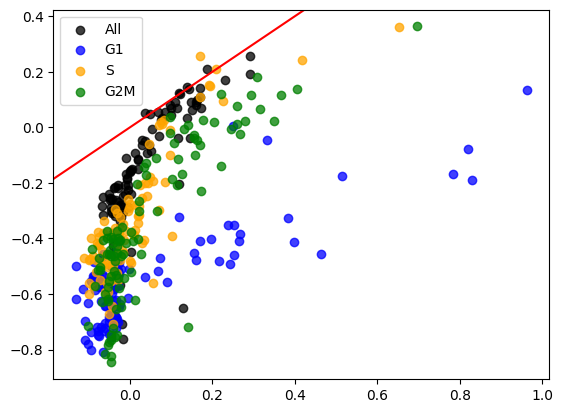

In [297]:
colours = ["black", "blue", "orange", "green"]
phases = ["All", "G1", "S", "G2M"]
d = 3
c = 95
for phase, colour in zip(labels, colours):
    plt.scatter(
        MF_interacting_df[f"{miRNA}_{phase}_c{c}_corr_OB"],
        MF_interacting_df[f"{miRNA}_{phase}_d{d}_c{c}_corr_MOSEK"],
        color=colour,
        label=phase,
        alpha=0.75
    )
plt.axline([0, 0], [0.01, 0.01], color="red")
plt.legend()

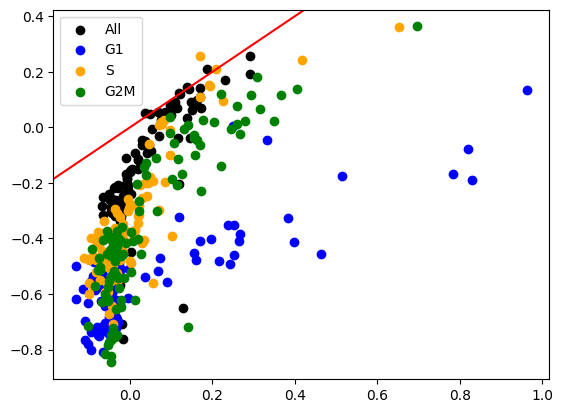

In [280]:
colours = ["black", "blue", "orange", "green"]
phases = ["All", "G1", "S", "G2M"]
d = 3
c = 95
for phase, colour in zip(labels, colours):
    plt.scatter(
        MF_interacting_df[f"{miRNA}_{phase}_c{c}_corr_OB"],
        MF_interacting_df[f"{miRNA}_{phase}_d{d}_c{c}_corr_MOSEK"],
        color=colour,
        label=phase
    )
plt.axline([0, 0], [0.01, 0.01], color="red")
plt.legend()

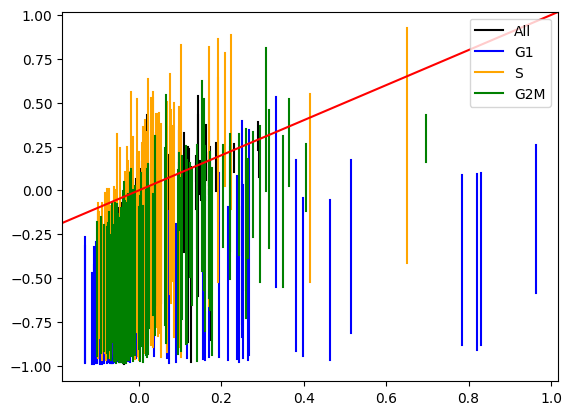

In [46]:
colours = ["black", "blue", "orange", "green"]
phases = ["All", "G1", "S", "G2M"]
for phase, colour in zip(phases, colours):
    corr_OB = MF_interacting_df[f"{miRNA}_{phase}_c{int(100*confidence)}_corr_OB"]
    corr_OG_min = MF_interacting_df[f"{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_HAR_min"]
    corr_OG_max = MF_interacting_df[f"{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_HAR_max"]
    label=phase
    for ob, mn, mx in zip(corr_OB, corr_OG_min, corr_OG_max):
        plt.plot([ob, ob], [mn, mx], color=colour, label=label)
        label=None
plt.axline([0, 0], [0.01, 0.01], color="red")
plt.legend()

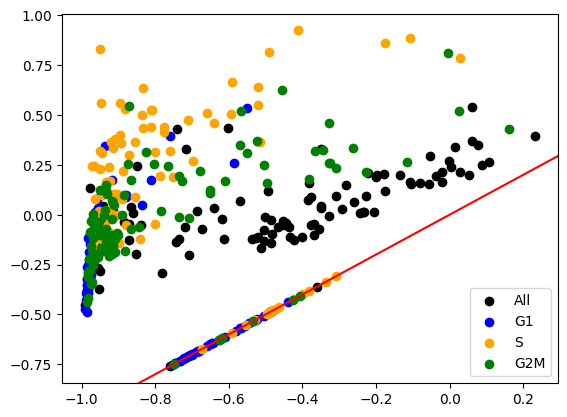

In [293]:
colours = ["black", "blue", "orange", "green"]
phases = ["All", "G1", "S", "G2M"]
for phase, colour in zip(phases, colours):
    corr_OB = MF_interacting_df[f"{miRNA}_{phase}_c{int(100*confidence)}_corr_OB"]
    corr_OG_min = MF_interacting_df[f"{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_HAR_min"]
    corr_OG_max = MF_interacting_df[f"{miRNA}_{phase}_d{d}_c{int(100*confidence)}_corr_HAR_max"]
    plt.scatter(corr_OG_min, corr_OG_max, color=colour, label=phase)
plt.axline([0, 0], [0.01, 0.01], color="red")
plt.legend()